<a href="https://colab.research.google.com/github/Jaideep-debug/DL/blob/main/DL_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Final Predictions:
Inputs:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
Predicted: [0 0 1 1]
Actual:    [0 1 1 0]
Final Accuracy: 0.5


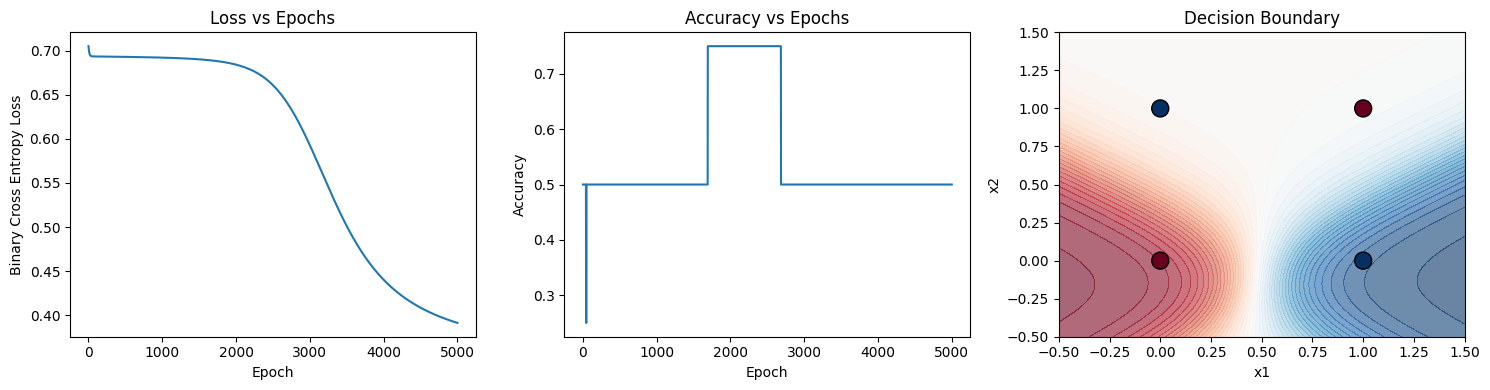

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# =========================
# 1. XOR Dataset
# =========================
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([0,1,1,0])

# =========================
# 2. Initialize Parameters
# =========================
np.random.seed(42)

input_size = 2
hidden_size = 2   # one hidden layer
output_size = 1

W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros(hidden_size)

W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros(output_size)

learning_rate = 0.1
epochs = 5000

loss_list = []
accuracy_list = []

# =========================
# 3. Activation Functions
# =========================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

# =========================
# 4. Training
# =========================
for epoch in range(epochs):

    # Forward
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    y_pred = sigmoid(z2).flatten()

    # Loss
    loss = -np.mean(y*np.log(y_pred+1e-9) +
                   (1-y)*np.log(1-y_pred+1e-9))
    loss_list.append(loss)

    # Backprop
    error_output = y_pred - y
    dW2 = np.dot(a1.T, error_output.reshape(-1,1)) / len(X)
    db2 = np.mean(error_output)

    error_hidden = np.dot(error_output.reshape(-1,1), W2.T) * sigmoid_derivative(a1)
    dW1 = np.dot(X.T, error_hidden) / len(X)
    db1 = np.mean(error_hidden, axis=0)

    # Update
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    # Accuracy
    preds = (y_pred >= 0.5).astype(int)
    acc = accuracy_score(y, preds)
    accuracy_list.append(acc)

# =========================
# 5. Final Output
# =========================
print("\nFinal Predictions:")
print("Inputs:\n", X)
print("Predicted:", preds)
print("Actual:   ", y)
print("Final Accuracy:", accuracy_list[-1])

# =========================
# 6. Plot Loss & Accuracy
# =========================
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(loss_list)
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")

plt.subplot(1,3,2)
plt.plot(accuracy_list)
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# =========================
# 7. Decision Boundary Plot
# =========================
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,200),
                     np.linspace(-0.5,1.5,200))

grid = np.c_[xx.ravel(), yy.ravel()]

# Forward pass for grid
z1 = np.dot(grid, W1) + b1
a1 = sigmoid(z1)
z2 = np.dot(a1, W2) + b2
Z = sigmoid(z2)
Z = Z.reshape(xx.shape)

plt.subplot(1,3,3)
plt.contourf(xx, yy, Z, levels=50, cmap="RdBu", alpha=0.6)
plt.scatter(X[:,0], X[:,1], c=y, cmap="RdBu", edgecolors="k", s=150)
plt.title("Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")

plt.tight_layout()
plt.show()
